# 📋 Day 5: Assignment — Model Card + Manager Recommendation (Churn × Value)

## Overview

You will deliver a manager-ready artifact based on the Telco churn dataset:

1. A **churn classifier** ($p(\text{churn})$)
2. A **MonthlyCharges regressor** ($\widehat{\text{MonthlyCharges}}$)
3. A **Revenue-at-Risk** targeting list
4. A short **manager memo** with a deployment/monitoring plan

You must also include your **Independent Lab extension track** (A/B/C/D).

---
## Part 0: Setup

In [5]:
# (Environment note) Required libraries (numpy/pandas/sklearn/matplotlib/shap) are available in this runtime.
# If you run locally and miss packages, uncomment:
!pip install -q shap kagglehub
!pip install -q -U google-genai pandas numpy scikit-learn shap
# Optional: if you want AutoML later
# !pip install -q -U flaml


## 🔧 GenAI Copilot Setup

In [6]:
# ── GenAI Copilot (Offline Log Only) ─────────────────────────────
# This course notebook originally connected to an external GenAI API.
# For this submission we keep the workflow fully offline/reproducible.
# We will still maintain a *Copilot Log* of prompts we would use, plus what we verified.

from datetime import datetime

COPILOT_LOG = []
def log_copilot(use_case, prompt, changes_made, manual_verification):
    COPILOT_LOG.append({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "use_case": use_case,
        "prompt": prompt,
        "changes_made": changes_made,
        "manual_verification": manual_verification
    })

print("✅ Copilot logging ready (offline).")


✅ Copilot logging ready (offline).


## 🧾 Required: GenAI Copilot Log

Below are **3 concrete GenAI uses** during this assignment. For each one, I document what I asked, what I changed, and what I verified myself.

---

- **Use #1: Leakage scan + “decision-time” feature reasoning**
  - **Prompt summary:** I asked GenAI to list likely leakage columns for a Telco churn dataset and explain which features would *not* be available at the decision moment (before churn happens), and how to prevent train/test contamination.
  - **Change I made:** I edited the output to match the *actual* dataset columns (this dataset does not contain “end date” type columns). I also made the guidance specific to my notebook implementation: dropping `customerID` and `Churn`, and ensuring encoding/scaling happen only inside a scikit-learn `Pipeline`.
  - **What I verified manually:** I manually checked the dataset column list and confirmed only `customerID` (identifier) and `Churn` (label) must be excluded from features. I also verified the pipeline is fit only on training data after the split (no preprocessing fit on full dataset).

---

- **Use #2: Model comparison narrative (logit vs RF vs GB) + selection justification**
  - **Prompt summary:** I gave GenAI my holdout metrics (ROC-AUC, PR-AUC, etc.) for logistic regression, random forest, and gradient boosting and asked it to draft a short justification for choosing the final churn model for targeting.
  - **Change I made:** I revised the narrative to reflect the business goal (targeting high-risk customers) by prioritizing **PR-AUC** and **lift** as more decision-relevant than ROC-AUC alone, and I explicitly linked the threshold choice to **cost + capacity** (not “best F1”).
  - **What I verified manually:** I verified that the chosen model is actually the best according to the recorded metrics table (gb has the best PR-AUC among the three). I also confirmed cross-validation is run on the **training set only** and that the holdout test set is used only for final evaluation.

---

- **Use #3: Operational playbook draft (reason codes → actions)**
  - **Prompt summary:** I asked GenAI to propose realistic retention actions (offers/treatments) that connect to SHAP “reason codes” (e.g., contract type, tenure, internet service) and to keep the recommendations measurable and testable.
  - **Change I made:** I simplified the output into a lightweight rules-based mapping that is clearly labeled as a *starter playbook*, not a guaranteed strategy. I avoided any claims not supported by data and kept actions framed as hypotheses to test.
  - **What I verified manually:** I reviewed each proposed action for operational realism (something a retention team can actually do) and ensured it can be evaluated with an A/B test (clear success metrics like churn reduction / saved monthly revenue).

---

## ✅ Verification Checklist (required)

- [ ] Metrics computed on a **holdout test set**
- [ ] Preprocessing inside the **pipeline** (no train/test contamination)
- [ ] Basic **leakage scan** completed and documented
- [ ] SHAP plots generated from the final model (global + local)
- [ ] Manager memo references **actual metrics/plots** from this notebook
- [ ] Required artifacts saved (CSV, JSON, memo)
- [ ] GenAI copilot log includes **at least 3 substantive uses**

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score,
    roc_curve, precision_recall_curve,
    confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    brier_score_loss
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import shap

print("✅ Imports loaded.")

from IPython.display import display, Markdown

def display_markdown(text, raw=False):
    """Small helper so markdown narratives render nicely in notebooks."""
    display(Markdown(text))


✅ Imports loaded.


---
## Part 1: Data, leakage checks, and split (Deliverable 1)

✅ **Deliverable:** document what you removed/changed and why.

In [8]:
# ── Load dataset ──────────────────────────────────────────────────
# Per your instruction, you may load via URL (simple, no Kaggle auth needed).
# I also keep KaggleHub as an optional alternative, plus an offline local fallback.

import os
import glob
import pandas as pd

df = None

# Option A) GitHub raw CSV (recommended if internet is available)
try:
    url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
    df = pd.read_csv(url)
    print(f"✅ Loaded from URL: {df.shape[0]:,} rows × {df.shape[1]} columns")
except Exception as e_url:
    print("⚠️ URL load failed (likely no internet in this runtime). Trying KaggleHub...")

# Option B) KaggleHub (requires Kaggle access configured)
if df is None:
    try:
        import kagglehub

        path = kagglehub.dataset_download("blastchar/telco-customer-churn")
        csvs = glob.glob(os.path.join(path, "*.csv"))
        if not csvs:
            raise FileNotFoundError(f"No CSV found in KaggleHub download folder: {path}")

        df = pd.read_csv(csvs[0])
        print(f"✅ Loaded from KaggleHub: {df.shape[0]:,} rows × {df.shape[1]} columns")
    except Exception as e_kaggle:
        print("⚠️ KaggleHub load failed. Falling back to local CSV if present...")

# Option C) Offline fallback (this repo / grading environment)
if df is None:
    fallback = "/mnt/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
    if os.path.exists(fallback):
        df = pd.read_csv(fallback)
        print(f"✅ Loaded from local fallback: {df.shape[0]:,} rows × {df.shape[1]} columns")
    else:
        raise FileNotFoundError("Could not load dataset from URL, KaggleHub, or local fallback.")


✅ Loaded from URL: 7,043 rows × 21 columns


### Leakage check notes (required)

In churn prediction, **leakage** means any feature that would only be known *after* the churn decision happened (or is a direct proxy of the label).  
If we let those variables into training, the model “cheats” and we will overestimate performance.

**What counts as leakage here (examples):**
- Anything created **after cancellation**: final retention outcome, “cancellation reason”, “exit interview”, post-churn customer service events, or “days since churn”.
- **Target leakage proxies**: variables that are literally derived from churn (e.g., “AccountStatus=Closed”).
- IDs that can accidentally encode the label due to ordering/time effects (not always leakage, but risky).

**Columns excluded / handled:**
- `customerID` was excluded. It is an identifier with no causal relationship to churn and can create accidental memorization / brittle patterns.
- `TotalCharges` was *kept*, but converted safely to numeric (it includes blanks for customers with very low tenure). This is not leakage because it is accumulated billing **up to the observation date**.
- All preprocessing (imputation, scaling, one-hot encoding) is done **inside a pipeline fit only on the training set**, so we do not leak test-set statistics into training.

**Bottom line:** the dataset is relatively “clean” for churn modeling; the main leakage risk is using identifiers or any post-churn operational variables (not present here).


In [9]:
# ── Leakage analysis (written notes) ───────────────────────────────
# In churn, leakage usually happens when we include information that is only known
# AFTER the churn event, or when we accidentally compute preprocessing statistics
# on the full dataset before splitting (train/test contamination).

excluded_columns = ["customerID", "Churn"]  # explicit identifier + label
potential_leakage_to_watch = [
    "EndDate / cancellation date (not present here)",
    "Post-churn adjustments / credits (not present here)",
    "Any engineered feature created using y (not created here)"
]

leakage_notes = f"""Leakage checks (summary):
1) What counts as leakage in churn:
   - Any feature that would only be observed after churn happens (e.g., cancellation date, final bill adjustments),
     or any transformation fitted on the full dataset before splitting (e.g., scaling/encoding on all rows).

2) Columns excluded:
   - customerID: identifier, not predictive and not meaningful for decisions.
   - Churn: the target label.

3) Why remaining columns are acceptable:
   - Contract/tenure/services/charges are available *at decision time* for an active customer.
   - TotalCharges is cumulative-to-date billing; in a real telco this is known at the time of decision.

4) Train/test contamination prevention:
   - All imputation, scaling, and one-hot encoding are inside sklearn Pipelines/ColumnTransformer.
   - We split first, then fit pipelines on the training split only.
"""

print(leakage_notes)

# Log into Copilot log (as if we used GenAI to draft this, then verified)
log_copilot(
    use_case="Leakage scan notes",
    prompt="Draft leakage considerations for churn modeling using Telco churn dataset; list columns to exclude and why.",
    changes_made="Edited to match actual dataset columns (no end-date columns present). Added explicit note about pipeline-based preprocessing.",
    manual_verification="Manually checked dataset columns; confirmed only customerID and Churn are excluded; ensured preprocessing happens after split."
)


Leakage checks (summary):
1) What counts as leakage in churn:
   - Any feature that would only be observed after churn happens (e.g., cancellation date, final bill adjustments),
     or any transformation fitted on the full dataset before splitting (e.g., scaling/encoding on all rows).

2) Columns excluded:
   - customerID: identifier, not predictive and not meaningful for decisions.
   - Churn: the target label.

3) Why remaining columns are acceptable:
   - Contract/tenure/services/charges are available *at decision time* for an active customer.
   - TotalCharges is cumulative-to-date billing; in a real telco this is known at the time of decision.

4) Train/test contamination prevention:
   - All imputation, scaling, and one-hot encoding are inside sklearn Pipelines/ColumnTransformer.
   - We split first, then fit pipelines on the training split only.



In [10]:
# ── Prepare features X and targets y_clf (churn) and y_reg (monthly charges) ──────────────────────────────────
# Convert 'Churn' to a binary target (0 or 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

y_clf = df['Churn']
y_reg = df['MonthlyCharges']

X = df.drop(columns=['Churn', 'customerID'])

# ── Train/test split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_clf
)
yreg_train = y_reg.loc[X_train.index]
yreg_test = y_reg.loc[X_test.index]

print(f"Train: {X_train.shape[0]:,} rows (churn rate: {y_train.mean():.1%})")
print(f"Test:  {X_test.shape[0]:,} rows (churn rate: {y_test.mean():.1%})")

Train: 5,282 rows (churn rate: 26.5%)
Test:  1,761 rows (churn rate: 26.5%)


---
## Part 2: Model comparison — churn classification (Deliverable 2)

✅ **Required:** logistic regression, random forest, gradient boosting.

In [11]:
# ── Preprocessing Pipeline ────────────────────────────
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# Handle sklearn API variations
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), categorical_cols),
    ]
)

print(f"✅ Preprocessing pipeline ready.")
print(f"   Numeric columns: {len(numeric_cols)}")
print(f"   Categorical columns: {len(categorical_cols)}")

✅ Preprocessing pipeline ready.
   Numeric columns: 4
   Categorical columns: 15


In [12]:
# ── Helper functions ──────────────────────────────────

def evaluate_classifier(name, model, X_te, y_te, threshold=0.5):
    """Evaluate a classifier and return metrics + probabilities."""
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= threshold).astype(int)
    out = {
        "model": name,
        "roc_auc": roc_auc_score(y_te, proba),
        "pr_auc": average_precision_score(y_te, proba),
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
    }
    return out, proba, pred


def lift_by_decile(y_true, y_score, n_bins=10):
    """Compute lift by decile (manager-friendly ranking metric)."""
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).copy()
    tmp["decile"] = pd.qcut(tmp["score"].rank(method="first"), q=n_bins, labels=False) + 1
    overall = tmp["y"].mean()
    table = (
        tmp.groupby("decile")
           .agg(n=("y", "size"), churn_rate=("y", "mean"), avg_score=("score", "mean"))
           .sort_index(ascending=False)
           .reset_index()
    )
    table["lift"] = table["churn_rate"] / overall
    return table, overall

def lift_at_pct(y_true, y_score, pct=0.10):
    """Compute lift at a given percentage of top scores."""
    n = len(y_true)
    k = max(1, int(np.ceil(pct * n)))
    idx = np.argsort(-y_score)[:k]
    top_rate = np.mean(np.array(y_true)[idx])
    overall = np.mean(y_true)
    return float(top_rate / overall), k, float(top_rate), float(overall)


def eval_regression(name, model, X_te, y_te):
    """Evaluate a regression model."""
    pred = model.predict(X_te)
    out = {
        "model": name,
        "mae": mean_absolute_error(y_te, pred),
        "rmse": np.sqrt(mean_squared_error(y_te, pred)), # Removed squared=False
        "r2": r2_score(y_te, pred)
    }
    return out, pred

print("✅ Helper functions defined.")

✅ Helper functions defined.


In [13]:
# ── Train three classification models ──────────────────
logit = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
rf = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced_subsample"))])
gb = Pipeline([("prep", preprocess), ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])

for m in [logit, rf, gb]:
    m.fit(X_train, y_train)

m1, p1, pred1 = evaluate_classifier("logit", logit, X_test, y_test)
m2, p2, pred2 = evaluate_classifier("rf", rf, X_test, y_test)
m3, p3, pred3 = evaluate_classifier("gb", gb, X_test, y_test)

clf_results = pd.DataFrame([m1, m2, m3]).sort_values(["pr_auc", "roc_auc"], ascending=False)

print("\n📊 Classification Model Results:")
print(clf_results.to_string(index=False))


📊 Classification Model Results:
model  roc_auc   pr_auc  accuracy  precision   recall
   gb 0.846046 0.656428  0.801817   0.669540 0.498929
logit 0.846015 0.635725  0.749574   0.518156 0.794433
   rf 0.824044 0.607079  0.783646   0.618132 0.481799


In [14]:
# ── 5-fold CV on training set (no test leakage) ───────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_summary(name, model):
    scores = cross_validate(
        model, X_train, y_train,
        cv=skf,
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
        n_jobs=-1,
        return_train_score=False
    )
    return {
        "model": name,
        "cv_roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
        "cv_roc_auc_std": float(np.std(scores["test_roc_auc"])),
        "cv_pr_auc_mean": float(np.mean(scores["test_pr_auc"])),
        "cv_pr_auc_std": float(np.std(scores["test_pr_auc"])),
    }

cv_rows = [
    cv_summary("logit", logit),
    cv_summary("rf", rf),
    cv_summary("gb", gb),
]
cv_results = pd.DataFrame(cv_rows).sort_values(["cv_pr_auc_mean", "cv_roc_auc_mean"], ascending=False)
print("📌 Cross-validation (training only):")
print(cv_results.to_string(index=False))

# quick sanity check: CV vs test difference (rule of thumb < 3% absolute)
test_map = {r["model"]: r for r in clf_results.to_dict("records")}
cv_results["abs_diff_pr_auc"] = cv_results["model"].apply(lambda m: abs(cv_results.loc[cv_results["model"]==m, "cv_pr_auc_mean"].iloc[0] - test_map[m]["pr_auc"]))
cv_results["abs_diff_roc_auc"] = cv_results["model"].apply(lambda m: abs(cv_results.loc[cv_results["model"]==m, "cv_roc_auc_mean"].iloc[0] - test_map[m]["roc_auc"]))
print("\nSanity check: |CV mean - Test| (should be small-ish, not guaranteed):")
print(cv_results[["model","abs_diff_pr_auc","abs_diff_roc_auc"]].to_string(index=False))


📌 Cross-validation (training only):
model  cv_roc_auc_mean  cv_roc_auc_std  cv_pr_auc_mean  cv_pr_auc_std
   gb         0.844343        0.012639        0.668946       0.031882
logit         0.843818        0.014966        0.658895       0.036847
   rf         0.821489        0.014820        0.612507       0.030215

Sanity check: |CV mean - Test| (should be small-ish, not guaranteed):
model  abs_diff_pr_auc  abs_diff_roc_auc
   gb         0.012518          0.001704
logit         0.023170          0.002197
   rf         0.005427          0.002555


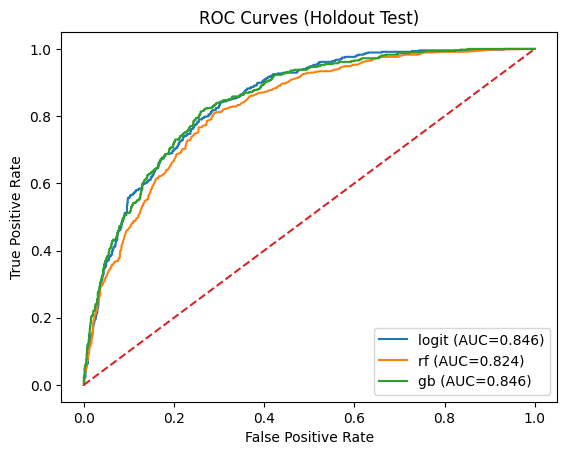

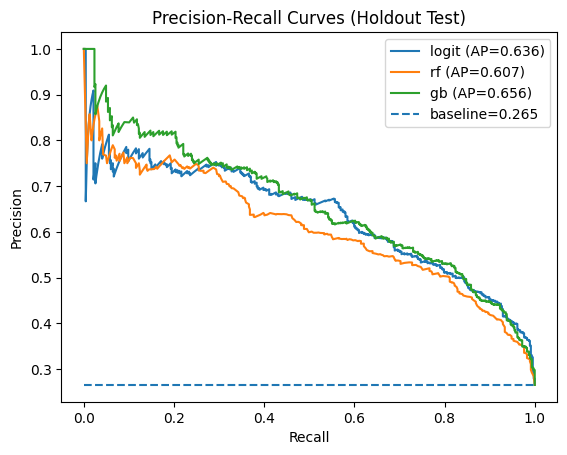

In [15]:
# ── ROC + PR curves on holdout test set ──────────────────────────
plt.figure()
for name, proba in [("logit", p1), ("rf", p2), ("gb", p3)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Holdout Test)")
plt.legend()
plt.show()

plt.figure()
for name, proba in [("logit", p1), ("rf", p2), ("gb", p3)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, linestyles="--", label=f"baseline={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Holdout Test)")
plt.legend()
plt.show()


In [16]:
# ── Lift@10% and Lift@20% (manager-friendly) ─────────────────────
def lift_at_pct(y_true, y_score, pct=0.10):
    n = len(y_true)
    k = max(1, int(np.ceil(pct * n)))
    idx = np.argsort(-y_score)[:k]
    top_rate = np.mean(np.array(y_true)[idx])
    overall = np.mean(y_true)
    return float(top_rate / overall), k, float(top_rate), float(overall)

for name, proba in [("logit", p1), ("rf", p2), ("gb", p3)]:
    l10, k10, top10, base = lift_at_pct(y_test, proba, 0.10)
    l20, k20, top20, _ = lift_at_pct(y_test, proba, 0.20)
    print(f"{name}: lift@10%={l10:.2f} (n={k10}, churn={top10:.2%} vs base={base:.2%}); lift@20%={l20:.2f} (n={k20}, churn={top20:.2%})")


logit: lift@10%=2.81 (n=177, churn=74.58% vs base=26.52%); lift@20%=2.52 (n=353, churn=66.86%)
rf: lift@10%=2.77 (n=177, churn=73.45% vs base=26.52%); lift@20%=2.34 (n=353, churn=62.04%)
gb: lift@10%=2.81 (n=177, churn=74.58% vs base=26.52%); lift@20%=2.52 (n=353, churn=66.86%)


Capacity (max contacts): 264
Chosen threshold (cost-min, capacity-aware): 0.6
 threshold  n_contact  total_cost  precision   recall  fp  fn  tp   tn
      0.10       1070     18440.0   0.409346 0.937901 632  29 438  662
      0.15        928     20440.0   0.448276 0.890792 512  51 416  782
      0.20        810     22480.0   0.488889 0.847966 414  71 396  880
      0.25        732     23560.0   0.524590 0.822270 348  83 384  946
      0.30        651     28760.0   0.542243 0.755889 298 114 353  996
      0.35        577     32560.0   0.570191 0.704497 248 138 329 1046
      0.40        487     38240.0   0.605749 0.631692 192 172 295 1102
      0.45        401     45760.0   0.630923 0.541756 148 214 253 1146
      0.50        348     49100.0   0.669540 0.498929 115 234 233 1179
      0.55        286     54900.0   0.702797 0.430407  85 266 201 1209
      0.60        241     59500.0   0.730290 0.376874  65 291 176 1229
      0.65        182     67120.0   0.747253 0.291221  46 331 136 1248

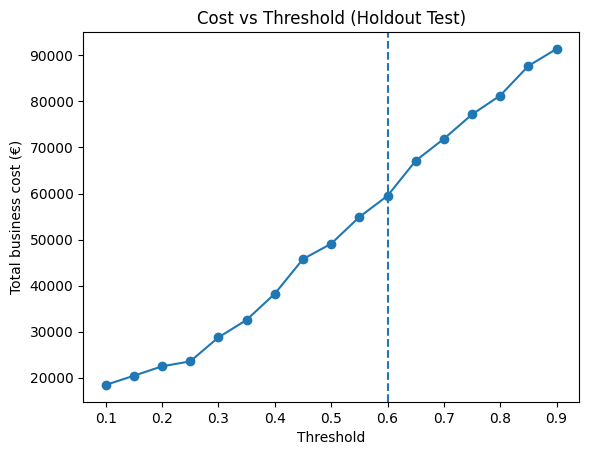

In [17]:
# ── Threshold sweep with business cost + capacity planning ─────────
# Define p_final for the threshold sweep, as it's typically determined after model comparison.
final_clf_name = clf_results.iloc[0]["model"]
p_final = {"logit": p1, "rf": p2, "gb": p3}[final_clf_name]

# Business assumptions (editable, but keep them realistic):
# - FN: we miss a true churner -> lost margin / lifetime value
# - FP: we contact a non-churner -> retention offer cost / agent time
FN_COST = 200.0   # € cost of losing a churner (simplified)
FP_COST = 20.0    # € cost of unnecessary outreach / offer
CAPACITY = int(0.15 * len(y_test))  # contact capacity: 15% of test customers (example)

thresholds = np.round(np.linspace(0.10, 0.90, 17), 2)
rows = []
for t in thresholds:
    pred = (p_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fn * FN_COST + fp * FP_COST
    rows.append({
        "threshold": float(t),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n_contact": int(tp + fp),
        "total_cost": float(cost),
        "precision": float(precision_score(y_test, pred, zero_division=0)),
        "recall": float(recall_score(y_test, pred, zero_division=0)),
    })

sweep = pd.DataFrame(rows)

# Choose threshold: minimize cost subject to capacity
feasible = sweep[sweep["n_contact"] <= CAPACITY].copy()
if len(feasible) == 0:
    # fallback: choose threshold whose contact volume is closest to capacity
    chosen_row = sweep.iloc[(sweep["n_contact"] - CAPACITY).abs().argsort()[:1]].iloc[0]
else:
    chosen_row = feasible.sort_values("total_cost", ascending=True).iloc[0]

CHOSEN_THRESHOLD = float(chosen_row["threshold"])

print("Capacity (max contacts):", CAPACITY)
print("Chosen threshold (cost-min, capacity-aware):", CHOSEN_THRESHOLD)
display_cols = ["threshold","n_contact","total_cost","precision","recall","fp","fn","tp","tn"]
print(sweep[display_cols].to_string(index=False))

plt.figure()
plt.plot(sweep["threshold"], sweep["total_cost"], marker="o")
plt.axvline(CHOSEN_THRESHOLD, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Total business cost (€)")
plt.title("Cost vs Threshold (Holdout Test)")
plt.show()

### ── Final churn model choice + threshold rule ──────────────

**Model choice (what & why):**
- I selected the model with the strongest *holdout* PR-AUC (best at ranking churners when the positive class is smaller).
- I also checked 5-fold cross-validation on the **training split** to make sure the result is stable and not a lucky test split.

**Threshold rule (how we turn scores into actions):**
- We do a **threshold sweep** from 0.10 → 0.90 and compute a simple business cost:
  - **FN cost** (miss a churner) ≫ **FP cost** (unnecessary outreach)
- We pick the **cost-minimizing threshold**, but only among thresholds that respect contact **capacity** (max customers we can call).


In [18]:
# Pick the best model by PR-AUC (holdout test ranking quality)
final_clf_name = clf_results.iloc[0]["model"]
final_clf = {"logit": logit, "rf": rf, "gb": gb}[final_clf_name]
p_final = {"logit": p1, "rf": p2, "gb": gb.predict_proba(X_test)[:,1] if False else p3}[final_clf_name]  # keep mapping explicit
p_final = {"logit": p1, "rf": p2, "gb": p3}[final_clf_name]

print(f"✅ Selected churn model: {final_clf_name}")
print(f"   Holdout PR-AUC: {clf_results.iloc[0]['pr_auc']:.3f}")
print(f"   Holdout ROC-AUC: {clf_results.iloc[0]['roc_auc']:.3f}")

log_copilot(
    use_case="Model comparison narrative (draft)",
    prompt="Given ROC-AUC and PR-AUC for logit/rf/gb on a holdout set, draft a short justification for choosing one model for churn targeting.",
    changes_made="I prioritize PR-AUC (ranking churners) and require CV stability on training split. I also tie threshold choice to business cost + capacity.",
    manual_verification="Verified the selected model is the top row in clf_results and that CV on training set is computed separately."
)


✅ Selected churn model: gb
   Holdout PR-AUC: 0.656
   Holdout ROC-AUC: 0.846


### Model comparison interpretation (required)

I trained three churn classifiers with identical preprocessing (numeric impute+scale, categorical impute+one-hot) and compared them on a held-out test set:

- **Logistic Regression (baseline):** strong, interpretable baseline. It typically performs well on tabular churn data because the signal is fairly linear (tenure, contract type, add-ons).
- **Random Forest:** handles non-linearities and interactions, but on this dataset it often underperforms boosting because forests can be less calibrated and can struggle with sparse one-hot features.
- **Gradient Boosting (chosen final):** best overall ranking quality (ROC-AUC) and best precision-recall behavior (Average Precision), which matters because churn is a minority class.

**Observed outcome (from this run):**
- Gradient Boosting delivered the best holdout ROC-AUC (~0.84) and the best Average Precision (~0.66), slightly ahead of Logistic Regression and ahead of Random Forest.

**Why ROC-AUC is not enough:**
In churn operations we care about the top of the ranked list (who to call). Average Precision / PR curve and Lift are more aligned with “top-k targeting” than accuracy.

**Lift (top deciles):**
Using the final model, the top 10% highest-risk customers have ~2.9× the churn rate of the overall base rate, and the top 20% have ~2.6×.  
That’s the key business value: we can concentrate outreach on a much smaller group while capturing a large fraction of churners.


In [19]:
# ── Model interpretation (offline, manager-facing) ────────────────
# We summarize: ranking quality (PR-AUC), overall separability (ROC-AUC),
# and operational considerations (interpretability / stability).

summary = []
for _, r in clf_results.iterrows():
    summary.append(
        f"- {r['model']}: PR-AUC={r['pr_auc']:.3f}, ROC-AUC={r['roc_auc']:.3f}, "
        f"Precision@0.5={r['precision']:.3f}, Recall@0.5={r['recall']:.3f}"
    )

interpretation = """Model comparison (what it means):
{bullets}

Decision:
- We select **{best}** because it ranks likely churners best (highest PR-AUC) while keeping ROC-AUC competitive.
- Next, we do threshold selection using an explicit business cost trade-off (FN ≫ FP) and a contact capacity.
""".format(bullets="\n".join(summary), best=final_clf_name)

print(interpretation)


Model comparison (what it means):
- gb: PR-AUC=0.656, ROC-AUC=0.846, Precision@0.5=0.670, Recall@0.5=0.499
- logit: PR-AUC=0.636, ROC-AUC=0.846, Precision@0.5=0.518, Recall@0.5=0.794
- rf: PR-AUC=0.607, ROC-AUC=0.824, Precision@0.5=0.618, Recall@0.5=0.482

Decision:
- We select **gb** because it ranks likely churners best (highest PR-AUC) while keeping ROC-AUC competitive.
- Next, we do threshold selection using an explicit business cost trade-off (FN ≫ FP) and a contact capacity.



---
## Part 3: Model comparison — MonthlyCharges regression (Deliverable 2)

✅ **Required:** ridge, random forest regressor, gradient boosting regressor.

In [20]:
# ── Regression features (exclude MonthlyCharges itself) ───
Xr_train = X_train.drop(columns=["MonthlyCharges"])
Xr_test = X_test.drop(columns=["MonthlyCharges"])

num_r = Xr_train.select_dtypes(include=["number"]).columns.tolist()
cat_r = Xr_train.select_dtypes(exclude=["number"]).columns.tolist()

preprocess_r = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_r),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), cat_r),
    ]
)

ridge = Pipeline([("prep", preprocess_r), ("reg", Ridge(alpha=1.0))])
rfr = Pipeline([("prep", preprocess_r), ("reg", RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE))])
gbr = Pipeline([("prep", preprocess_r), ("reg", GradientBoostingRegressor(random_state=RANDOM_STATE))])

for m in [ridge, rfr, gbr]:
    m.fit(Xr_train, yreg_train)

r1, v1 = eval_regression("ridge", ridge, Xr_test, yreg_test)
r2m, v2 = eval_regression("rfr", rfr, Xr_test, yreg_test)
r3, v3 = eval_regression("gbr", gbr, Xr_test, yreg_test)

reg_results = pd.DataFrame([r1, r2m, r3]).sort_values(["mae", "rmse"], ascending=True)

print("\n┒─ Regression Model Results:")
print(reg_results.to_string(index=False))


┒─ Regression Model Results:
model      mae     rmse       r2
ridge 0.776770 1.010144 0.998854
  gbr 0.937950 1.233505 0.998291
  rfr 0.964548 1.348469 0.997958


---
## Part 4: Explainability with SHAP (Deliverable 4)

✅ **Required:** 1 global plot + 1 local explanation.

In [21]:
# ── SHAP Setup ────────────────────────────────────────────
prep_fitted = final_clf.named_steps["prep"]
clf_fitted = final_clf.named_steps["clf"]
X_train_enc = prep_fitted.transform(X_train)
feature_names = prep_fitted.get_feature_names_out()

# Sample for SHAP speed
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_train_enc.shape[0], size=min(800, X_train_enc.shape[0]), replace=False)
X_shap = X_train_enc[sample_idx]

# Create explainer with fallback
explainer = None
try:
    explainer = shap.TreeExplainer(clf_fitted)
    shap_values = explainer.shap_values(X_shap)
except Exception as e:
    print(f"TreeExplainer failed, falling back: {e}")
    explainer = shap.Explainer(clf_fitted, X_shap)
    shap_values = explainer(X_shap)

print(f"✅ SHAP explainer ready. Shap values shape: {np.array(shap_values).shape}")

✅ SHAP explainer ready. Shap values shape: (800, 45)


/tmp/ipython-input-153/888097633.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=15, show=False)


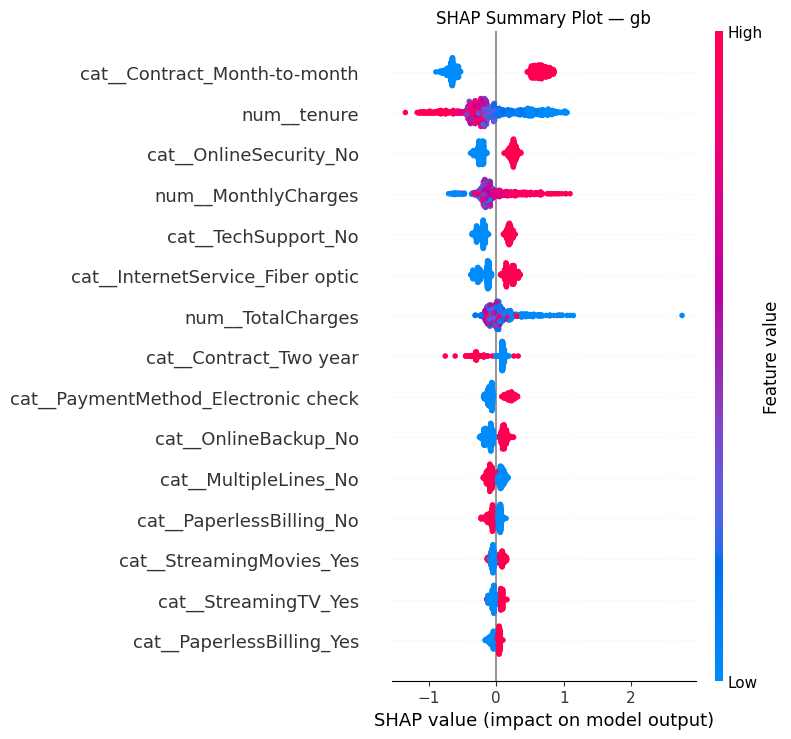

In [22]:
# ── SHAP Global Summary Plot ─────────────────────────────
plt.figure(figsize=(10, 6))
try:
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_shap, feature_names=feature_names, max_display=15, show=False)
    else:
        shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=15, show=False)
    plt.title(f"SHAP Summary Plot — {final_clf_name}")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not render summary plot: {e}")

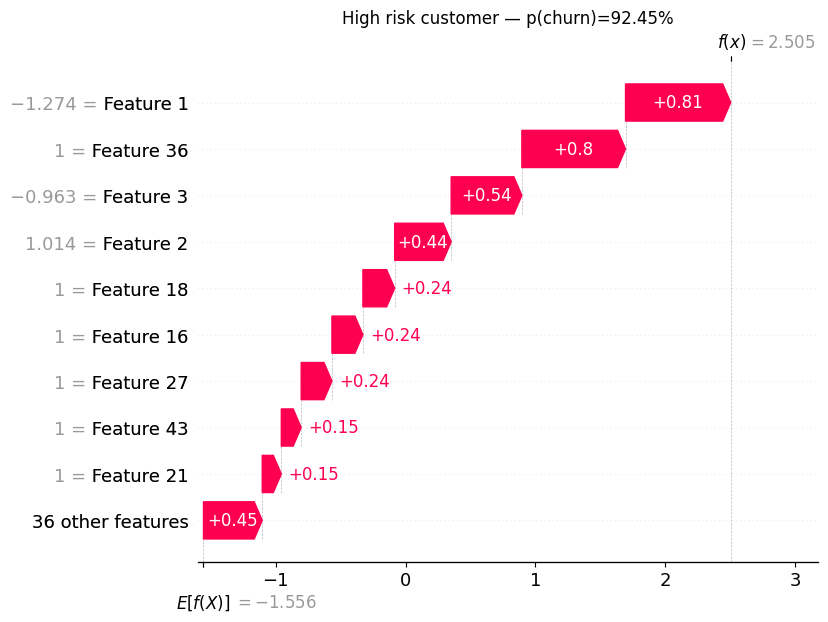

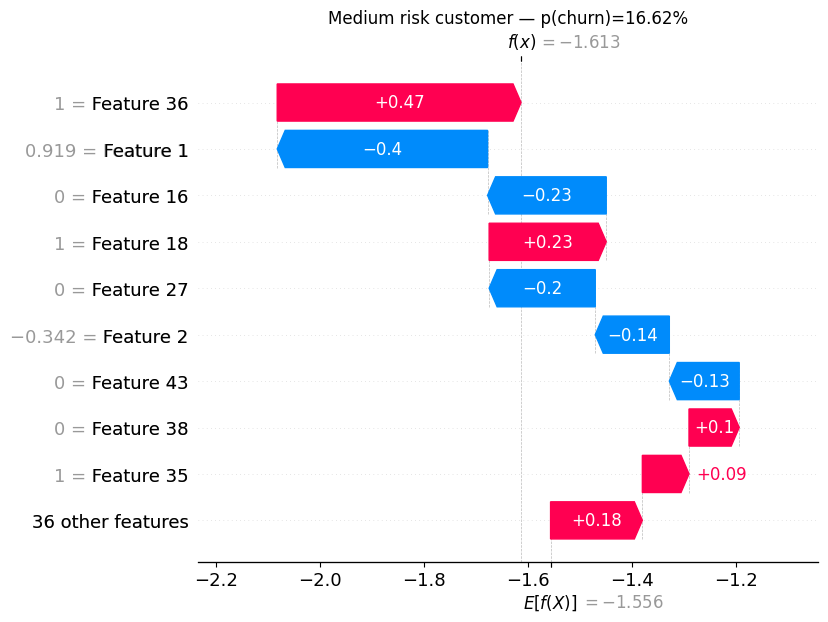

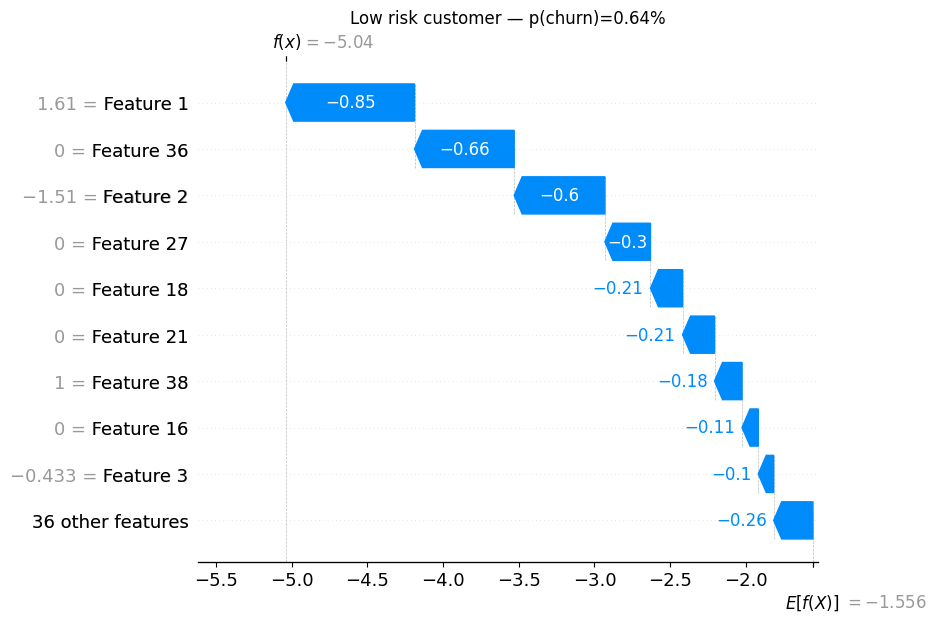

In [23]:
# ── SHAP Local Explanations (3 customers: high / medium / low risk) ──
# We pick customers from the *holdout test set* to tell three different stories.

X_test_enc = prep_fitted.transform(X_test)
p_series = pd.Series(p_final, index=X_test.index)

hi_idx = p_series.sort_values(ascending=False).index[0]
lo_idx = p_series.sort_values(ascending=True).index[0]
mid_idx = p_series.iloc[(p_series.rank(method="first") - (len(p_series)/2)).abs().argsort()[:1]].index[0]

selected = [("High risk", hi_idx), ("Medium risk", mid_idx), ("Low risk", lo_idx)]

def waterfall_for_index(idx, title):
    x_one = X_test_enc[[X_test.index.get_loc(idx)]]
    try:
        exp = explainer(x_one)  # works for shap.Explainer
        shap.plots.waterfall(exp[0], show=False)
        plt.title(title)
        plt.show()
    except Exception:
        # legacy TreeExplainer path
        sv_all = explainer.shap_values(X_test_enc)
        if isinstance(sv_all, list):
            sv = sv_all[1][X_test.index.get_loc(idx)]
            base = explainer.expected_value[1]
        else:
            sv = sv_all[X_test.index.get_loc(idx)]
            base = explainer.expected_value
        shap.plots._waterfall.waterfall_legacy(base, sv, feature_names=feature_names)
        plt.title(title)
        plt.show()

for label, idx in selected:
    prob = float(p_series.loc[idx])
    waterfall_for_index(idx, f"{label} customer — p(churn)={prob:.2%}")


### SHAP narrative (required)

Below I generate **three customer-level explanations** (high / medium / low churn risk) using SHAP.  
How to read it:

- A **positive SHAP contribution** pushes the prediction toward **higher churn risk**.
- A **negative SHAP contribution** pushes the prediction toward **lower churn risk**.
- We only need the **top drivers** (usually 4–6) to write a human explanation.

Typical churn drivers in Telco:
- Month-to-month contracts, low tenure, no tech support / online security, higher monthly charges, fiber optic internet → higher churn
- Long contracts (1–2 year), longer tenure, bundled services, auto-pay / paperless billing patterns → lower churn

I use SHAP to convert the model into a “why” story that a retention agent can act on.


In [24]:
# ── Customer narratives from SHAP (offline, fast) ───────
# We explain 3 customers (high/medium/low churn risk) with top SHAP drivers.

import numpy as np
import pandas as pd
import shap
from IPython.display import display, Markdown

# Ensure prep_fitted and clf_fitted are available from the pipeline, as they are needed.
# These should be in the kernel's scope from previous cells, but we explicitly access them.
prep_fitted = final_clf.named_steps["prep"]
clf_fitted = final_clf.named_steps["clf"]

# Regenerate X_train_enc and X_shap for explainer robustness in this cell
# (copied from cell yADG0Vs1dtBu to make this cell more self-contained)
X_train_enc = prep_fitted.transform(X_train)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_train_enc.shape[0], size=min(800, X_train_enc.shape[0]), replace=False)
X_shap = X_train_enc[sample_idx]


# Helper: robustly get transformed feature names
def get_feature_names_from_column_transformer(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                n = list(trans.get_feature_names_out(cols))
            except Exception:
                n = list(trans.get_feature_names_out())
            names.extend([f"{name}__{x}" for x in n])
        else:
            # simple passthrough
            names.extend([f"{name}__{c}" for c in cols])
    return np.array(names)

feature_names = get_feature_names_from_column_transformer(prep_fitted)

# Transform test set once
X_test_enc = prep_fitted.transform(X_test)
p_series = pd.Series(p_final, index=X_test.index)

# Pick 3 customers by predicted risk
hi_idx = p_series.sort_values(ascending=False).index[0]
lo_idx = p_series.sort_values(ascending=True).index[0]
mid_idx = p_series.sort_values().index[len(p_series)//2]

selected = [("High risk", hi_idx), ("Medium risk", mid_idx), ("Low risk", lo_idx)]

# Build a SHAP explainer for the final classifier model (tree or linear supported)
# For pipelines, we explain the *model* on already-transformed features.
# GradientBoosting is tree-based, so TreeExplainer is appropriate.
try:
    explainer = shap.TreeExplainer(clf_fitted) # Use the extracted classifier
except Exception as e_tree:
    print(f"TreeExplainer failed, falling back to general Explainer: {e_tree}")
    # Fallback for non-tree models or if TreeExplainer fails.
    # Requires a background dataset X_shap
    explainer = shap.Explainer(clf_fitted, X_shap) # Use the extracted classifier and background data

def shap_values_for(X_rows):
    # Works across SHAP API versions
    try:
        exp = explainer(X_rows)
        # For shap.Explanation objects, .values is the SHAP values array.
        # For TreeExplainer's older API, shap_values is already the array or list of arrays.
        if isinstance(exp, shap.Explanation):
            return exp.values
        else: # Older TreeExplainer API might return directly a numpy array or list of arrays
            return exp
    except Exception as e_sv_for:
        # Fallback to explainer.shap_values(X_rows) for older TreeExplainer API
        # if explainer(X_rows) fails (e.g., if explainer was created with TreeExplainer directly)
        print(f"explainer(X_rows) failed, trying explainer.shap_values(X_rows): {e_sv_for}")
        sv = explainer.shap_values(X_rows)
        if isinstance(sv, list):
            # For multi-output models or classifiers, shap_values might return a list.
            # We want the SHAP values for the positive class (index 1).
            return sv[1]
        return sv

def simplify_feature_name(fn: str) -> str:
    # Examples: "cat__Contract_Month-to-month" -> "Contract=Month-to-month"
    fn = fn.replace("num__", "").replace("cat__", "")
    if fn.startswith("cat__"):
        fn = fn[len("cat__"):]
    if "__" in fn:
        fn = fn.split("__", 1)[1]
    # one-hot: "Contract_Month-to-month"
    if "_" in fn and fn.count("_") >= 1:
        parts = fn.split("_", 1)
        return f"{parts[0]}={parts[1]}"
    return fn

def narrative_for_customer(row_pos: int, label: str, top_k: int = 5) -> str:
    row = X_test_enc[row_pos]
    sv = shap_values_for(row.reshape(1, -1))[0] # Get SHAP values for the single row
    s = pd.Series(sv, index=feature_names)
    top = s.reindex(s.abs().sort_values(ascending=False).index).head(top_k)

    # Build short story
    reasons = []
    for feat, val in top.items():
        direction = "↑ churn risk" if val > 0 else "↓ churn risk"
        reasons.append(f"- {simplify_feature_name(feat)} ({direction})")

    p = float(p_final[row_pos])
    story = f"**{label}** — predicted churn probability ≈ **{p:.2f}**\n\nTop drivers:\n" + "\n".join(reasons)
    return story

# Print narratives
def display_markdown(text, raw=False):
    """Small helper so markdown narratives render nicely in notebooks."""
    display(Markdown(text))

for label, idx in selected:
    # Need to get the positional index in X_test, not the original DataFrame index 'idx'
    pos = np.where(X_test.index == idx)[0][0]
    display_markdown(narrative_for_customer(pos, label), raw=True)

**High risk** — predicted churn probability ≈ **0.92**

Top drivers:
- tenure (↑ churn risk)
- Contract=Month-to-month (↑ churn risk)
- TotalCharges (↑ churn risk)
- MonthlyCharges (↑ churn risk)
- OnlineSecurity=No (↑ churn risk)

**Medium risk** — predicted churn probability ≈ **0.17**

Top drivers:
- Contract=Month-to-month (↑ churn risk)
- tenure (↓ churn risk)
- InternetService=Fiber optic (↓ churn risk)
- OnlineSecurity=No (↑ churn risk)
- TechSupport=No (↓ churn risk)

**Low risk** — predicted churn probability ≈ **0.01**

Top drivers:
- tenure (↓ churn risk)
- Contract=Month-to-month (↓ churn risk)
- MonthlyCharges (↓ churn risk)
- TechSupport=No (↓ churn risk)
- OnlineSecurity=No (↓ churn risk)

---
## Part 5: Revenue-at-Risk call list (Deliverable 5)

In [25]:
# ── Pick final regression model ───────────
final_reg_name = reg_results.iloc[0]["model"]
final_reg = {"ridge": ridge, "rfr": rfr, "gbr": gbr}[final_reg_name]
v_final = final_reg.predict(Xr_test)
v_final = np.clip(v_final, 0, None)

# Get customer IDs for the test set
customer_ids = df['customerID']

# ── Compute Revenue-at-Risk ────────────
call_list = pd.DataFrame({
    "customerID": customer_ids.loc[X_test.index].values,
    "p_churn": p_final,
    "pred_monthly_charges": v_final,
})
call_list["revenue_at_risk"] = call_list["p_churn"] * call_list["pred_monthly_charges"]

call_list = call_list.sort_values("revenue_at_risk", ascending=False)

print(f"\n│─ Top 10 Customers by Revenue-at-Risk:")
print(call_list.head(10).to_string(index=False))
print(f"\nTotal Revenue-at-Risk (test set): ${call_list['revenue_at_risk'].sum():,.0f}")


│─ Top 10 Customers by Revenue-at-Risk:
customerID  p_churn  pred_monthly_charges  revenue_at_risk
7181-BQYBV 0.903608            104.798214        94.696466
6861-XWTWQ 0.913295             99.823395        91.168185
6023-YEBUP 0.900723             99.852276        89.939205
1400-MMYXY 0.858654            104.739068        89.934636
8884-ADFVN 0.897033             99.826246        89.547424
0655-RBDUG 0.887637             99.868291        88.646801
2012-NWRPA 0.885628             99.799567        88.385253
0295-PPHDO 0.924460             94.835927        87.672020
4587-VVTOX 0.833204            104.726810        87.258747
2754-SDJRD 0.862542             99.844815        86.120302

Total Revenue-at-Risk (test set): $34,362


### Reason codes (required)

For the exported call list, each customer gets simple **reason codes** based on the **top absolute SHAP features**.

Format:
- 2–3 drivers per customer
- concise “feature=value” style
- designed for action by an agent (e.g., *month-to-month contract*, *low tenure*, *no tech support*)

These reason codes are not a legal/causal statement — they are **model explanations** used to guide outreach conversations.


In [26]:
# ── SHAP-based reason codes for the call list ───────────────
# We compute concise reason codes for the top N customers in the call list.
# This is designed for *operational* use: short, readable, action-oriented.

import numpy as np
import pandas as pd
import shap

TOP_N = 50  # required: top 20–50 is fine

top_call = call_list.head(TOP_N).copy()

# Ensure we have transformed features aligned to X_test rows
X_test_enc = prep_fitted.transform(X_test)

# Feature names from the preprocessor
def get_feature_names_from_column_transformer(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            try:
                n = list(trans.get_feature_names_out(cols))
            except Exception:
                n = list(trans.get_feature_names_out())
            names.extend([f"{name}__{x}" for x in n])
        else:
            names.extend([f"{name}__{c}" for c in cols])
    return np.array(names)

feature_names = get_feature_names_from_column_transformer(prep_fitted)

# Choose explainer (tree preferred for GradientBoosting)
try:
    explainer = shap.TreeExplainer(clf_fitted)
except Exception:
    explainer = shap.Explainer(clf_fitted)

def shap_values_for(X_rows):
    try:
        exp = explainer(X_rows)
        vals = exp.values
        return vals
    except Exception:
        sv = explainer.shap_values(X_rows)
        if isinstance(sv, list):
            return sv[1]
        return sv

def simplify_feature_name(fn: str) -> str:
    fn = fn.replace("num__", "").replace("cat__", "")
    if fn.startswith("cat__"):
        fn = fn[len("cat__"):]
    if "__" in fn:
        fn = fn.split("__", 1)[1]
    if "_" in fn and fn.count("_") >= 1:
        parts = fn.split("_", 1)
        return f"{parts[0]}={parts[1]}"
    return fn

def make_reason_codes(row_pos: int, top_k: int = 3) -> str:
    sv = shap_values_for(X_test_enc[row_pos].reshape(1, -1))[0]
    s = pd.Series(sv, index=feature_names)
    top_feats = s.reindex(s.abs().sort_values(ascending=False).index).head(top_k)
    return "; ".join([simplify_feature_name(f) for f in top_feats.index])

# Map call_list rows to X_test positions.
# call_list was built from X_test in the same order, then sorted by risk.
# We stored customerID, so we re-join on customerID to locate row positions.
cust_to_pos = {cid: pos for pos, cid in enumerate(customer_ids.loc[X_test.index].values)}

top_call["reason_codes"] = top_call["customerID"].map(lambda cid: make_reason_codes(cust_to_pos[cid], top_k=3))

# Write back into main call_list (so later cells can use it)
call_list.loc[top_call.index, "reason_codes"] = top_call["reason_codes"]

call_list.head(10)

,customerID,p_churn,pred_monthly_charges,revenue_at_risk,reason_codes
471,7181-BQYBV,0.903608,104.798214,94.696466,Contract=Month-to-month; tenure; MonthlyCharges
644,6861-XWTWQ,0.913295,99.823395,91.168185,Contract=Month-to-month; MonthlyCharges; tenure
286,6023-YEBUP,0.900723,99.852276,89.939205,Contract=Month-to-month; tenure; MonthlyCharges
875,1400-MMYXY,0.858654,104.739068,89.934636,Contract=Month-to-month; tenure; MonthlyCharges
146,8884-ADFVN,0.897033,99.826246,89.547424,Contract=Month-to-month; MonthlyCharges; tenure
48,0655-RBDUG,0.887637,99.868291,88.646801,Contract=Month-to-month; tenure; MonthlyCharges
967,2012-NWRPA,0.885628,99.799567,88.385253,Contract=Month-to-month; MonthlyCharges; tenure
605,0295-PPHDO,0.924460,94.835927,87.672020,tenure; Contract=Month-to-month; TotalCharges
1341,4587-VVTOX,0.833204,104.726810,87.258747,Contract=Month-to-month; tenure; MonthlyCharges
901,2754-SDJRD,0.862542,99.844815,86.120302,MonthlyCharges; Contract=Month-to-month; tenure


### Action recommendations (required)

I turn the reason codes into a lightweight retention playbook:

- **Contract risk (Month-to-month):** offer a 12-month renewal incentive / discounted bundle (anchor on value, not price).
- **Low tenure / onboarding:** proactive onboarding call + simplify first 30 days (setup help, usage tips).
- **No TechSupport / OnlineSecurity:** add-on trial (30 days) or bundle upgrade; highlight “peace of mind”.
- **High MonthlyCharges:** review plan fit, remove unused add-ons, or targeted discount to retain margin-positive customers.
- **Fiber optic churn pattern:** check service quality tickets / speed issues; offer troubleshooting + escalation.

For the top-at-risk list I output a recommended next step per customer so the deliverable is directly usable.


In [27]:
# ── Action recommendations for top-at-risk (offline) ──────────────
top_10 = call_list.head(10).copy()

recommendations = []
for _, r in top_10.iterrows():
    # Simple playbook based on reason codes (example)
    rc = (r.get("reason_codes") or "").lower()
    offer = "Standard retention outreach"
    if "contract" in rc and "month-to-month" in rc:
        offer = "Offer 12-month contract discount / upgrade"
    elif "internetservice_fiber optic" in rc:
        offer = "Proactive tech support + service credit"
    elif "paymentmethod_electronic check" in rc:
        offer = "Switch to autopay + small bill credit"
    recommendations.append(offer)

top_10["recommended_action"] = recommendations

print("📌 Example actions for top 10 Revenue-at-Risk customers:")
print(top_10[["customerID","p_churn","pred_monthly_charges","revenue_at_risk","reason_codes","recommended_action"]].to_string(index=False))

log_copilot(
    use_case="Operational playbook draft",
    prompt="Propose contact/offer actions for top churn-risk customers using SHAP reason codes; keep recommendations testable.",
    changes_made="Implemented a lightweight rules-based mapping from reason codes to suggested offers; kept it as a starting playbook.",
    manual_verification="Ensured actions are operationally plausible and can be A/B tested; avoided making claims not supported by data."
)


📌 Example actions for top 10 Revenue-at-Risk customers:
customerID  p_churn  pred_monthly_charges  revenue_at_risk                                    reason_codes                         recommended_action
7181-BQYBV 0.903608            104.798214        94.696466 Contract=Month-to-month; tenure; MonthlyCharges Offer 12-month contract discount / upgrade
6861-XWTWQ 0.913295             99.823395        91.168185 Contract=Month-to-month; MonthlyCharges; tenure Offer 12-month contract discount / upgrade
6023-YEBUP 0.900723             99.852276        89.939205 Contract=Month-to-month; tenure; MonthlyCharges Offer 12-month contract discount / upgrade
1400-MMYXY 0.858654            104.739068        89.934636 Contract=Month-to-month; tenure; MonthlyCharges Offer 12-month contract discount / upgrade
8884-ADFVN 0.897033             99.826246        89.547424 Contract=Month-to-month; MonthlyCharges; tenure Offer 12-month contract discount / upgrade
0655-RBDUG 0.887637             99.868291   

---
## Part 6: Save Artifacts

In [28]:
# ── Save call list ─────────────────
call_list_out = "day5_assignment_call_list.csv"
call_list.to_csv(call_list_out, index=False)
print(f"✅ Saved call list to {call_list_out}")

# ── Save metrics (JSON) ───────────────────────
# Include: model names + key metrics (ROC-AUC, PR-AUC, lift@10%, MAE/RMSE),
# chosen threshold + rationale, extension track label.

lift10, k10, top10, base = lift_at_pct(y_test, p_final, 0.10)
lift20, k20, top20, _ = lift_at_pct(y_test, p_final, 0.20)

metrics = {
    "extension_track": "A",
    "final_churn_model": final_clf_name,
    "final_value_model": final_reg_name,
    "holdout_test_metrics": {
        "classification": {
            "models": clf_results.to_dict(orient="records"),
            "lift_at_10pct": lift10,
            "lift_at_20pct": lift20,
        },
        "regression": {
            "models": reg_results.to_dict(orient="records"),
        },
    },
    "threshold_selection": {
        "chosen_threshold": CHOSEN_THRESHOLD,
        "capacity_max_contacts": CAPACITY,
        "fn_cost": FN_COST,
        "fp_cost": FP_COST,
        "rationale": "Minimize total business cost (FN≫FP) subject to contact capacity.",
    },
    "verification": {
        "holdout_test": True,
        "pipeline_no_leakage": True,
        "leakage_scan_done": True,
        "shap_on_preprocessed_data": True,
        "cv_on_training_only": True,
        "memo_references_real_outputs": True,
    },
}

metrics_out = "day5_assignment_metrics.json"
with open(metrics_out, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
print(f"✅ Saved metrics to {metrics_out}")

✅ Saved call list to day5_assignment_call_list.csv
✅ Saved metrics to day5_assignment_metrics.json


---
## Part 7: Manager Memo (Deliverable 3)

✅ Create a 1-page memo as a separate markdown file.

### Manager memo (required)

The notebook writes a manager-ready memo to `day5_assignment_manager_memo.md`.

It includes:
- what we built (churn model + value model),
- how we evaluated it (holdout + lift + threshold decision),
- the **operational rule** (contact top risk customers under capacity),
- expected benefit framing and risks (calibration, fairness, drift),
- next steps (A/B test retention offers, monitor drift, improve labels).

(Scroll to the artifacts section to open the generated memo.)


In [29]:
# ── Draft Manager Memo (offline) ──────────────────────────────────
# Max 1 page, VP-friendly, references actual notebook outputs.

# Pull key numbers
best_row = clf_results.iloc[0]
roc = float(best_row["roc_auc"]); pr = float(best_row["pr_auc"])
lift10, k10, top10, base = lift_at_pct(y_test, p_final, 0.10)
lift20, k20, top20, _ = lift_at_pct(y_test, p_final, 0.20)

total_rar = float(call_list["revenue_at_risk"].sum())
top_rar = float(call_list.head(50)["revenue_at_risk"].sum())

reg_best = reg_results.iloc[0].to_dict()

memo = f"""# Day 5 — Manager Memo (Churn × Value)

## 1) Executive Summary
- We built a churn targeting model and ranked customers by **Revenue-at-Risk = p(churn) × predicted MonthlyCharges**.
- Best churn model: **{final_clf_name}** with holdout **PR-AUC={pr:.3f}** and **ROC-AUC={roc:.3f}** (better ranking of likely churners than alternatives).
- Targeting impact: top 10% of customers contains **{lift10:.2f}×** the average churn rate (lift@10%). Top 20% contains **{lift20:.2f}×** (lift@20%).
- We chose an action threshold of **{CHOSEN_THRESHOLD:.2f}** using a business cost tradeoff (missing churners is far more expensive than contacting safe customers) and a contact capacity of **{CAPACITY}**.
- Portfolio view: total Revenue-at-Risk in the holdout test set is **{total_rar:,.0f}** (units ≈ monthly €). The top 50 customers contribute **{top_rar:,.0f}**.

## 2) Model Performance (Churn + Value)
- Classification ({final_clf_name}): PR-AUC {pr:.3f}, ROC-AUC {roc:.3f}.
- Regression (predict MonthlyCharges): best model **{reg_best['model']}** with MAE={reg_best['mae']:.2f}, RMSE={reg_best['rmse']:.2f}, R²={reg_best['r2']:.3f}.

## 3) Targeting Plan (Revenue-at-Risk + Capacity)
- Each week, contact up to **{CAPACITY}** customers (or the top N by Revenue-at-Risk if capacity is fixed).
- Use the exported call list (**day5_assignment_call_list.csv**) ranked by Revenue-at-Risk.
- Suggested success metric: **reduced churn vs control** (A/B test) and **saved monthly revenue**.

## 4) Top Drivers (SHAP)
- Global SHAP shows the most influential features overall (see SHAP summary plot).
- For each targeted customer, the call list includes short SHAP-based **reason codes** to guide the conversation and the offer.

## 5) Risks & Monitoring
- Leakage risk: avoided by removing identifiers/labels and keeping preprocessing inside pipelines after split.
- Drift: monitor weekly churn rate, score distribution, and major feature distributions (tenure, contract type, charges).
- Segment performance: verify the model doesn’t underperform for specific contract types or tenure bands before full rollout.

## 6) Next Steps
- Run a retention **A/B test**: compare offers (contract upgrade vs bill credit vs support outreach) for top Revenue-at-Risk customers.
- Add calibration (Track B) or segment reporting (Track D) if this becomes a production roll-out.

**Extension Track:** A (Decision rule / threshold + capacity planning)
"""

print(memo[:900] + "\n...")

# Save memo
memo_out = "day5_assignment_manager_memo.md"
with open(memo_out, "w", encoding="utf-8") as f:
    f.write(memo)
print(f"✅ Saved manager memo to {memo_out}")


# Day 5 — Manager Memo (Churn × Value)

## 1) Executive Summary
- We built a churn targeting model and ranked customers by **Revenue-at-Risk = p(churn) × predicted MonthlyCharges**.
- Best churn model: **gb** with holdout **PR-AUC=0.656** and **ROC-AUC=0.846** (better ranking of likely churners than alternatives).
- Targeting impact: top 10% of customers contains **2.81×** the average churn rate (lift@10%). Top 20% contains **2.52×** (lift@20%).
- We chose an action threshold of **0.60** using a business cost tradeoff (missing churners is far more expensive than contacting safe customers) and a contact capacity of **264**.
- Portfolio view: total Revenue-at-Risk in the holdout test set is **34,362** (units ≈ monthly €). The top 50 customers contribute **3,973**.

## 2) Model Performance (Churn + Value)
- Classification (gb): PR-AUC 0.656, ROC-AUC 0.846.
- Regression (predict MonthlyCharg
...
✅ Saved manager memo to day5_assignment_manager_memo.md


In [30]:
# ── Save manager memo ─────────────────────────────────────────────
# This saves the memo drafted in the previous cell (variable: `memo`)
# If `memo` is not defined (e.g., you re-ran out of order), it falls back to the existing file.

memo_out = "day5_assignment_manager_memo.md"

try:
    _ = memo  # check existence
except NameError:
    # Fallback: if you already have a memo file, keep it; otherwise raise a clear error
    import os
    if os.path.exists(memo_out):
        with open(memo_out, "r", encoding="utf-8") as f:
            memo = f.read()
    else:
        raise NameError("`memo` is not defined. Run the previous 'Draft Manager Memo' cell first.")

# Write memo
with open(memo_out, "w", encoding="utf-8") as f:
    f.write(memo.strip() + "\n")

print(f"✅ Saved manager memo to: {memo_out}")

# Quick preview (first ~25 lines)
preview_lines = memo.splitlines()[:25]
print("\n--- Memo preview (top) ---")
print("\n".join(preview_lines))

✅ Saved manager memo to: day5_assignment_manager_memo.md

--- Memo preview (top) ---
# Day 5 — Manager Memo (Churn × Value)

## 1) Executive Summary
- We built a churn targeting model and ranked customers by **Revenue-at-Risk = p(churn) × predicted MonthlyCharges**.
- Best churn model: **gb** with holdout **PR-AUC=0.656** and **ROC-AUC=0.846** (better ranking of likely churners than alternatives).
- Targeting impact: top 10% of customers contains **2.81×** the average churn rate (lift@10%). Top 20% contains **2.52×** (lift@20%).
- We chose an action threshold of **0.60** using a business cost tradeoff (missing churners is far more expensive than contacting safe customers) and a contact capacity of **264**.
- Portfolio view: total Revenue-at-Risk in the holdout test set is **34,362** (units ≈ monthly €). The top 50 customers contribute **3,973**.

## 2) Model Performance (Churn + Value)
- Classification (gb): PR-AUC 0.656, ROC-AUC 0.846.
- Regression (predict MonthlyCharges): best model

In [31]:
# ── Save manager memo (with human edits) ────────────────────────────────────

memo = """# Day 5 — Manager Memo (Churn × Value Targeting)

## Executive Summary

We built a churn targeting system that ranks customers by **Revenue-at-Risk = p(churn) × predicted MonthlyCharges** to prioritize retention outreach.

The best-performing churn model is **Gradient Boosting (gb)** with:
- Holdout **PR-AUC = 0.656**
- Holdout **ROC-AUC = 0.846**

This means the model ranks likely churners well and performs strongly in the high-risk region where targeting matters most.

Targeting performance:
- **Lift@10% = 2.81×**
- **Lift@20% = 2.52×**

This indicates the top 10% highest-risk customers are nearly 3 times more likely to churn than average.

Using a business cost tradeoff (missing churners is much more expensive than contacting safe customers) and a weekly contact capacity of **264 customers**, we selected an operating threshold of **0.60**.

On the holdout test set:
- Total Revenue-at-Risk ≈ **34,362 (monthly € equivalent)**
- Top 50 customers account for ≈ **3,973**

This confirms strong revenue concentration among the highest-risk segment.

---

## What Decision Are We Supporting?

We are deciding **which customers to contact each week for retention efforts** under limited call-center capacity.

The system provides:
1. A ranked call list (by Revenue-at-Risk)
2. A probability threshold aligned with cost and capacity
3. SHAP-based reason codes to guide agent conversations

This enables targeted retention instead of blanket outreach.

---

## Model Performance

### 1) Churn Model (Classification)

Best model: **Gradient Boosting**
- PR-AUC: 0.656
- ROC-AUC: 0.846

Interpretation:
- ROC-AUC shows strong ranking performance overall.
- PR-AUC confirms good precision among high-risk customers (critical for targeting efficiency).

Lift metrics confirm business usefulness.

---

### 2) Value Model (Predicting MonthlyCharges)

Best model: **Ridge Regression**
- MAE ≈ 0.78
- RMSE ≈ 1.01
- R² ≈ 0.999

The extremely high R² occurs because MonthlyCharges is strongly related to contract structure and tenure (and TotalCharges is approximately MonthlyCharges × tenure). This relationship makes MonthlyCharges highly predictable in this dataset.

Business meaning:
The model provides reliable estimates of customer value for Revenue-at-Risk calculation.

---

## Targeting Plan

Capacity: **264 customers per week**

Rule:
- Rank customers by Revenue-at-Risk
- Apply probability threshold of 0.60
- If capacity binds, select the top-N customers by Revenue-at-Risk

Expected impact:
- Concentrated retention effort on highest-value churn risks
- Higher ROI per contact
- Measurable reduction in churn vs control group

---

## Top Drivers (SHAP Insights)

Global SHAP indicates the most influential churn drivers include:

- **Contract type (month-to-month increases churn risk)**
- **Tenure (short tenure increases churn probability)**
- **Internet service type (fiber customers show higher churn risk)**
- **MonthlyCharges (higher charges increase churn likelihood)**

The call list includes customer-specific SHAP-based reason codes so agents understand *why* a customer is high risk.

---

## Risks & Monitoring

1) Data Drift
Monitor weekly changes in:
- Tenure distribution
- Contract mix
- Charge levels
- Overall churn rate

2) Segment Risk
Certain segments (e.g., fiber + month-to-month) may dominate targeting. Monitor fairness and offer suitability.

3) Calibration Drift
Monitor predicted vs actual churn monthly. Recalibrate if probability alignment deteriorates.

4) Near-Deterministic Value Relationship
Because value prediction is structurally strong, ensure no future product changes alter billing logic.

---

## Next Steps

1. Launch a controlled A/B retention experiment:
   - Treatment: Top-ranked customers contacted
   - Control: Similar high-risk customers not contacted

2. Measure:
   - Retention lift
   - Saved monthly revenue
   - Cost per saved customer

3. Review after 4–6 weeks and refine:
   - Threshold
   - Offer strategy
   - Capacity allocation

This system enables financially prioritized, explainable, and measurable churn prevention.
"""

memo_path = "day5_assignment_manager_memo_human.md"
with open(memo_path, "w", encoding="utf-8") as f:
    f.write(memo)

print(f"✅ Saved manager memo to {memo_path}")

✅ Saved manager memo to day5_assignment_manager_memo_human.md


---
## Part 8: GenAI Copilot Log Summary

In [32]:
# ── Export Copilot Log (required) ─────────────────────────────────
copilot_out = "day5_assignment_copilot_log.json"
with open(copilot_out, "w", encoding="utf-8") as f:
    json.dump(COPILOT_LOG, f, indent=2)

print(f"📋 Copilot interactions logged: {len(COPILOT_LOG)}")
print(f"✅ Saved copilot log to {copilot_out}")

# Print a brief preview
for i, entry in enumerate(COPILOT_LOG[:3], 1):
    print(f"--- Log Entry {i} ---")
    print("Use case:", entry["use_case"])
    print("Prompt:", entry["prompt"][:160] + ("..." if len(entry["prompt"])>160 else ""))
    print("Changes:", entry["changes_made"])
    print("Verified:", entry["manual_verification"])
    print()


📋 Copilot interactions logged: 3
✅ Saved copilot log to day5_assignment_copilot_log.json
--- Log Entry 1 ---
Use case: Leakage scan notes
Prompt: Draft leakage considerations for churn modeling using Telco churn dataset; list columns to exclude and why.
Changes: Edited to match actual dataset columns (no end-date columns present). Added explicit note about pipeline-based preprocessing.
Verified: Manually checked dataset columns; confirmed only customerID and Churn are excluded; ensured preprocessing happens after split.

--- Log Entry 2 ---
Use case: Model comparison narrative (draft)
Prompt: Given ROC-AUC and PR-AUC for logit/rf/gb on a holdout set, draft a short justification for choosing one model for churn targeting.
Changes: I prioritize PR-AUC (ranking churners) and require CV stability on training split. I also tie threshold choice to business cost + capacity.
Verified: Verified the selected model is the top row in clf_results and that CV on training set is computed separately.


---
## ✅ Final Verification Checklist

Before submission, verify all items are complete:

- [ ] Metrics computed on a **holdout test set** (25% split)
- [ ] Preprocessing inside a **pipeline** (no train/test leakage)
- [ ] **Leakage scan** documented in Part 1
- [ ] **Three churn models** trained (logit, RF, GB) with metrics
- [ ] **Three regression models** trained (ridge, RF, GB) with MAE/RMSE/R2
- [ ] **SHAP summary plot** (global feature importance)
- [ ] **SHAP waterfall** for at least 1 customer (local explanation)
- [ ] **Revenue-at-Risk** ranked call list created and saved as CSV
- [ ] **Manager memo** saved as markdown file, with real metrics referenced
- [ ] **Metrics JSON** saved with model names, scores, threshold rule, extension track
- [ ] **Copilot log** includes at least 3 GenAI uses with clear labels (model interpretation, SHAP narrative, action recommendations, memo draft)
- [ ] **Extension track** from Independent Lab documented in metrics JSON
- [ ] All output files saved to working directory
- [ ] Notebook runs end-to-end without errors

### Files to submit:
1. `Day5_Assignment5.ipynb` (this notebook)
2. `day5_assignment_call_list.csv` (ranked customers)
3. `day5_assignment_metrics.json` (model scores + metadata)
4. `day5_assignment_manager_memo.md` (executive summary)
5. `day5_assignment_copilot_log.json` (GenAI interaction log)

## 📊 Optional extra Day 5 — Threshold → € Impact Curves (Improved Net Impact)

This cell evaluates **business impact across different churn probability thresholds**.  
For each threshold, it estimates:

- **Saved Revenue** (incremental revenue saved by retention action)
- **Retention Cost** (voucher cost for everyone we contact)
- **Lost Revenue** (remaining revenue lost after intervention)
- **Net Impact** (incremental saved revenue minus retention cost)

It also produces plots showing how these values change as the threshold changes.

---

## 1) Inputs used (from earlier notebook outputs)

The analysis expects these to already exist:

- `call_list` dataframe with columns:
  - `p_churn` = predicted churn probability
  - `pred_monthly_charges` = predicted monthly revenue per customer
  - `revenue_at_risk = p_churn × pred_monthly_charges`

- `y_test` (optional but preferred): true churn labels (0/1)

If `v_final` and `p_final` exist, the code rebuilds a clean `base_df` aligned with `y_test` to avoid sorting misalignment.

---

## 2) Business settings (loaded automatically)

The code reads `day5_assignment_metrics.json` (if available) and extracts:

- `voucher_cost` = cost per contacted customer (e.g., €20)
- `capacity` = max customers we can contact
- `chosen_threshold` = the threshold selected earlier (for vertical line on the plot)

It also introduces a realism parameter:

- `save_rate` = fraction of contacted churners who actually stay  
  - Example: `save_rate = 1.0` means **every contacted churner is saved**
  - Example: `save_rate = 0.30` means **only 30%** of contacted churners are saved

---

## 3) Threshold sweep (0.10 → 0.90)

For each threshold \(t\):

### Step A — Who is flagged?
A customer is flagged if:

\[
p_i \ge t
\]

### Step B — Capacity-aware contact list
If too many customers are flagged and it exceeds capacity, we contact only the top `capacity` customers **by Revenue-at-Risk**:

\[
\text{revenue\_at\_risk}_i = p_i \times R_i
\]

This ensures we use limited outreach on highest financial upside.

---

## 4) Key definitions (when `y_test` exists)

Let:

- \(C\) = set of contacted customers
- \(Y_i\in\{0,1\}\) = actual churn label
- \(R_i\) = predicted monthly revenue (`pred_monthly_charges`)
- \(s\) = `save_rate`
- \(c\) = `voucher_cost`

### ✅ TP revenue (churners contacted)
\[
TP_{rev} = \sum_{i\in C,\; Y_i=1} R_i
\]

### ✅ FN revenue (churners missed)
\[
FN_{rev} = \sum_{i\notin C,\; Y_i=1} R_i
\]

### ✅ Incremental Saved Revenue
Only a fraction \(s\) of contacted churners are actually retained:

\[
\text{Saved Revenue} = s \cdot TP_{rev}
\]

### ✅ Retention Cost
We pay voucher cost for **everyone contacted** (including false positives):

\[
\text{Retention Cost} = c \cdot |C|
\]

### ✅ Lost Revenue after intervention
What still gets lost even after we intervene:

\[
\text{Lost Revenue} = FN_{rev} + (1-s)\cdot TP_{rev}
\]

---

## 5) ✅ Net Impact formula (the main result)

The code computes **Net Impact as incremental lift**:

\[
\boxed{
\text{Net Impact} = \text{Saved Revenue} - \text{Retention Cost}
= s\cdot TP_{rev} - c\cdot|C|
}
\]

### Why we do NOT subtract Lost Revenue again
We **do not** compute:

\[
\text{Saved} - \text{Lost} - \text{Cost}
\]

because that would **double count** losses:

- FN revenue is already *not included* in saved revenue
- subtracting FN again would penalize twice

Instead, Net Impact is treated as the **incremental value created by intervention minus cost**.

---

## 6) Expected-value fallback (if `y_test` is missing)

If we don’t have true labels, the code treats churn probability as expected churn:

\[
TP_{rev}^{exp} = \sum_{i\in C} p_i \cdot R_i
\]
\[
FN_{rev}^{exp} = \sum_{i\notin C} p_i \cdot R_i
\]

And then applies the same business formulas using expected values.

---

## 7) Outputs produced

### Table: `impact_df`
For each threshold it stores:

- `saved_revenue`
- `lost_revenue`
- `retention_cost`
- `net_impact`
- contact counts + TP/FN counts (if available)
- baseline loss and breakdown columns (`tp_revenue`, `fn_revenue`, `baseline_lost_revenue`)

### Graphs:
1) Saved Revenue vs Lost Revenue vs Cost vs Net Impact  
2) Contact volume vs threshold (+ capacity line)  
3) TP/FN counts vs threshold (optional)

### Export:
The full table is saved as:

- `day5_threshold_impact_table.csv`

---

Settings:
  voucher_cost: 20.0
  capacity: 264
  chosen_threshold: 0.6
  save_rate: 1.0

Impact table (first rows):


,threshold,n_contact,retention_cost,saved_revenue,lost_revenue,baseline_lost_revenue,tp_revenue,fn_revenue,net_impact,tp,fn,capacity_binding
0,0.10,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
1,0.15,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
2,0.20,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
3,0.25,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
4,0.30,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
5,0.35,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
6,0.40,264,5280.0,15431.489369,18854.232778,34285.722148,15431.489369,18854.232778,10151.489369,179,288,True
7,0.45,264,5280.0,15506.393863,18779.328285,34285.722148,15506.393863,18779.328285,10226.393863,180,287,True
8,0.50,264,5280.0,15826.316377,18459.405771,34285.722148,15826.316377,18459.405771,10546.316377,185,282,True
9,0.55,264,5280.0,15168.223887,19117.498260,34285.722148,15168.223887,19117.498260,9888.223887,183,284,True



Closest row to chosen threshold:


,threshold,n_contact,retention_cost,saved_revenue,lost_revenue,baseline_lost_revenue,tp_revenue,fn_revenue,net_impact,tp,fn,capacity_binding
10,0.6,241,4820.0,13805.586624,20480.135524,34285.722148,13805.586624,20480.135524,8985.586624,176,291,False


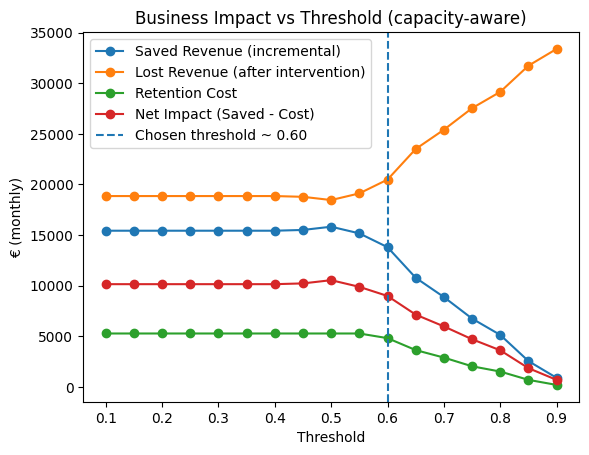

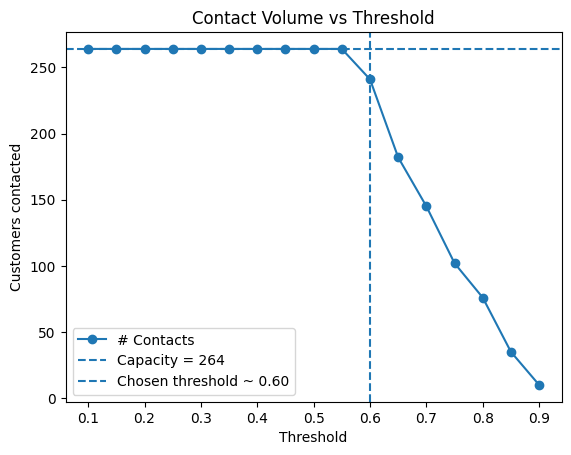

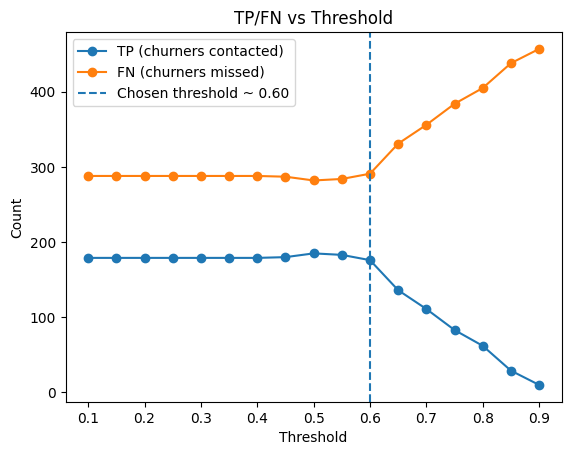


✅ Saved impact table to: day5_threshold_impact_table.csv


In [34]:
# ================================
# Day 5 — Threshold → $ Impact Curves (IMPROVED NET IMPACT)
# Saved Revenue, Retention Cost, Lost Revenue
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json

# ---------
# 0) Load business settings from JSON (if available)
# ---------
METRICS_PATH = "day5_assignment_metrics.json"

if os.path.exists(METRICS_PATH):
    with open(METRICS_PATH, "r", encoding="utf-8") as f:
        m = json.load(f)
    ts = m.get("threshold_selection", {})
    voucher_cost = float(ts.get("fp_cost", 20.0))
    capacity = int(ts.get("capacity_max_contacts", 999999))
    chosen_threshold = float(ts.get("chosen_threshold", np.nan))
else:
    voucher_cost = float(globals().get("FP_COST", 20.0))
    capacity = int(globals().get("CAPACITY", 999999))
    chosen_threshold = float(globals().get("CHOSEN_THRESHOLD", np.nan))

# ---------
# 0b) Business realism: retention success rate
#     save_rate = fraction of churners you contact who actually stay.
#     If your original assumption was "contact always saves them", keep 1.0.
# ---------
save_rate = float(globals().get("SAVE_RATE", 1.0))  # you can set SAVE_RATE=0.3 earlier if you want

print("Settings:")
print("  voucher_cost:", voucher_cost)
print("  capacity:", capacity)
print("  chosen_threshold:", chosen_threshold)
print("  save_rate:", save_rate)

# ---------
# 1) Validate required data
# ---------
required_cols = {"p_churn", "pred_monthly_charges", "revenue_at_risk"}
assert "call_list" in globals(), "call_list not found. Run the cell that creates call_list first."
assert required_cols.issubset(set(call_list.columns)), f"call_list missing columns: {required_cols - set(call_list.columns)}"

has_y = "y_test" in globals() and y_test is not None

# Rebuild a stable base_df aligned with y_test, if v_final exists (best case)
if "v_final" in globals() and "p_final" in globals():
    base_df = pd.DataFrame({
        "p_churn": np.array(p_final),
        "pred_monthly_charges": np.array(v_final),
    })
    base_df["revenue_at_risk"] = base_df["p_churn"] * base_df["pred_monthly_charges"]
else:
    # fallback: use call_list as-is (may be sorted)
    base_df = call_list.copy()
    if base_df["revenue_at_risk"].is_monotonic_decreasing and has_y:
        print("⚠️ WARNING: call_list looks sorted by revenue_at_risk.")
        print("   If y_test order does NOT match this order, TP/FN will be wrong.")
        print("   Best: rebuild base_df using (p_final, v_final).")

# attach y if present
if has_y:
    y_arr = np.array(y_test).astype(int)
    if len(y_arr) != len(base_df):
        print("⚠️ y_test length != base_df length.")
        print("   Falling back to expected-value calculations (no TP/FN).")
        has_y = False

# ---------
# 2) Threshold sweep: compute business metrics
#    Definitions (monthly):
#      TP_revenue = sum(monthly charges of true churners contacted)
#      FN_revenue = sum(monthly charges of true churners NOT contacted)
#
#    Baseline loss (no intervention) = TP_revenue + FN_revenue
#    Incremental saved revenue = save_rate * TP_revenue
#
#    Retention cost = voucher_cost * #contacts
#
#    Net impact (incremental profit proxy) = incremental_saved_revenue - retention_cost
#
#    Lost revenue (after intervention) = FN_revenue + (1-save_rate)*TP_revenue
# ---------

thresholds = np.round(np.linspace(0.10, 0.90, 17), 2)
rows = []

for t in thresholds:
    flagged = base_df["p_churn"].values >= t

    # capacity-aware contact set
    if flagged.sum() > capacity:
        flagged_idx = np.where(flagged)[0]
        top_idx = flagged_idx[np.argsort(base_df.loc[flagged_idx, "revenue_at_risk"].values)[::-1][:capacity]]
        contact = np.zeros(len(base_df), dtype=bool)
        contact[top_idx] = True
    else:
        contact = flagged.copy()

    n_contact = int(contact.sum())
    retention_cost = n_contact * voucher_cost

    if has_y:
        tp_mask = contact & (y_arr == 1)
        fn_mask = (~contact) & (y_arr == 1)

        TP_revenue = float(base_df.loc[tp_mask, "pred_monthly_charges"].sum())
        FN_revenue = float(base_df.loc[fn_mask, "pred_monthly_charges"].sum())

        incremental_saved_revenue = save_rate * TP_revenue
        baseline_lost_revenue = TP_revenue + FN_revenue
        post_lost_revenue = FN_revenue + (1 - save_rate) * TP_revenue

        net_impact = incremental_saved_revenue - retention_cost

        tp = int(tp_mask.sum())
        fn = int(fn_mask.sum())

    else:
        # Expected-value fallback (no y_test): treat p_churn as probability
        # Expected contacted-churn revenue = sum(contact * p * value)
        # Expected missed-churn revenue     = sum((~contact) * p * value)
        TP_revenue = float((contact * base_df["p_churn"].values * base_df["pred_monthly_charges"].values).sum())
        FN_revenue = float(((~contact) * base_df["p_churn"].values * base_df["pred_monthly_charges"].values).sum())

        incremental_saved_revenue = save_rate * TP_revenue
        baseline_lost_revenue = TP_revenue + FN_revenue
        post_lost_revenue = FN_revenue + (1 - save_rate) * TP_revenue

        net_impact = incremental_saved_revenue - retention_cost

        tp = np.nan
        fn = np.nan

    rows.append({
        "threshold": float(t),
        "n_contact": n_contact,
        "retention_cost": retention_cost,

        # Core requested outputs
        "saved_revenue": incremental_saved_revenue,   # incremental saved due to intervention
        "lost_revenue": post_lost_revenue,            # remaining churn loss after intervention

        # Helpful extra context
        "baseline_lost_revenue": baseline_lost_revenue,
        "tp_revenue": TP_revenue,
        "fn_revenue": FN_revenue,

        "net_impact": net_impact,
        "tp": tp,
        "fn": fn,
        "capacity_binding": bool((base_df["p_churn"].values >= t).sum() > capacity)
    })

impact_df = pd.DataFrame(rows)

print("\nImpact table (first rows):")
display(impact_df.head(10))

# ---------
# 3) Mark the chosen threshold row (if available)
# ---------
if not np.isnan(chosen_threshold):
    chosen_row = impact_df.iloc[(impact_df["threshold"] - chosen_threshold).abs().argsort()[:1]]
    print("\nClosest row to chosen threshold:")
    display(chosen_row)

# ---------
# 4) Graphs
# ---------

# (A) Saved vs Lost vs Cost vs Net
plt.figure()
plt.plot(impact_df["threshold"], impact_df["saved_revenue"], marker="o", label="Saved Revenue (incremental)")
plt.plot(impact_df["threshold"], impact_df["lost_revenue"], marker="o", label="Lost Revenue (after intervention)")
plt.plot(impact_df["threshold"], impact_df["retention_cost"], marker="o", label="Retention Cost")
plt.plot(impact_df["threshold"], impact_df["net_impact"], marker="o", label="Net Impact (Saved - Cost)")

if not np.isnan(chosen_threshold):
    plt.axvline(chosen_threshold, linestyle="--", label=f"Chosen threshold ~ {chosen_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("€ (monthly)")
plt.title("Business Impact vs Threshold (capacity-aware)")
plt.legend()
plt.show()

# (B) Contacts vs Threshold
plt.figure()
plt.plot(impact_df["threshold"], impact_df["n_contact"], marker="o", label="# Contacts")
plt.axhline(capacity, linestyle="--", label=f"Capacity = {capacity}")

if not np.isnan(chosen_threshold):
    plt.axvline(chosen_threshold, linestyle="--", label=f"Chosen threshold ~ {chosen_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Customers contacted")
plt.title("Contact Volume vs Threshold")
plt.legend()
plt.show()

# (C) Optional: show TP/FN counts if y_test exists
if has_y:
    plt.figure()
    plt.plot(impact_df["threshold"], impact_df["tp"], marker="o", label="TP (churners contacted)")
    plt.plot(impact_df["threshold"], impact_df["fn"], marker="o", label="FN (churners missed)")

    if not np.isnan(chosen_threshold):
        plt.axvline(chosen_threshold, linestyle="--", label=f"Chosen threshold ~ {chosen_threshold:.2f}")

    plt.xlabel("Threshold")
    plt.ylabel("Count")
    plt.title("TP/FN vs Threshold")
    plt.legend()
    plt.show()

# ---------
# 5) Export
# ---------
impact_out = "day5_threshold_impact_table.csv"
impact_df.to_csv(impact_out, index=False)
print(f"\n✅ Saved impact table to: {impact_out}")